In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [9]:
model = models.Sequential([
    layers.Input(shape=(26,)), 
    
    # Layer 1: Wide feature extraction with Batch Normalization for stability
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),
    
    # Layers 2-4: Deep logic processing
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    # Output: Probability of Player 1 winning
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [15]:
# Path to the dataset (notebook is in src/, data is in ../data/)
data_path = os.path.join('..', 'data', 'dataset2.csv')

# Load the dataset
print("Loading dataset... this might take a moment.")
df = pd.read_csv(data_path)

# Separate features (25 board positions + 1 turn) and label
X = df.iloc[:, 0:26].values
y = df['label'].values

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Loading dataset... this might take a moment.
Total samples: 315234
Training samples: 252187
Testing samples: 63047


In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=8,
    restore_best_weights=True 
)

history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=512,
    validation_split=0.2, 
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6874 - val_loss: 0.6966
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.7713 - val_loss: 1.1855
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.3483 - val_loss: 1.8718
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3.1334 - val_loss: 4.5396
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 3.0427 - val_loss: 3.4801
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.1851 - val_loss: 5.9011
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4.7931 - val_loss: 11.0361
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6.8554 - val_loss: 4.3182
Epoch 9/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 8.1595 - val_loss: 9.2170



Evaluating on Test Set...
FINAL TEST LOSS (Binary Cross-Entropy): 0.6381


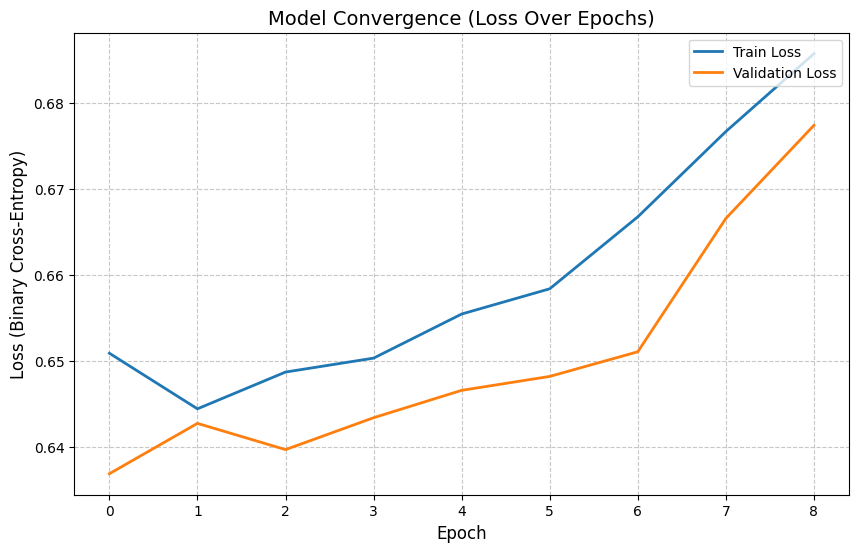

In [14]:
# 1. Evaluate on the completely unseen Test Set
print("\nEvaluating on Test Set...")
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"FINAL TEST LOSS (Binary Cross-Entropy): {test_loss:.4f}")

# 2. Plotting the Learning Curve (Loss Only)
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Model Convergence (Loss Over Epochs)', fontsize=14)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [17]:
# Only run this cell when you are satisfied with the model's performance
model_filename = 'model.keras'
model.save(model_filename)
print(f"SUCCESS: Model saved securely as '{model_filename}' in the src folder.")

SUCCESS: Model saved securely as 'model.keras' in the src folder.
